In [ ]:
#Load Data
import pandas as pd

splits = {
    'train': 'plain_text/train-00000-of-00001.parquet',
    'test': 'plain_text/test-00000-of-00001.parquet',
    'unsupervised': 'plain_text/unsupervised-00000-of-00001.parquet'
}

train_df = pd.read_parquet("hf://datasets/stanfordnlp/imdb/" + splits["train"])
test_df = pd.read_parquet("hf://datasets/stanfordnlp/imdb/" + splits["test"])

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print(train_df.head())

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Train shape: (25000, 2)
Test shape: (25000, 2)
                                                text  label
0  I rented I AM CURIOUS-YELLOW from my video sto...      0
1  "I Am Curious: Yellow" is a risible and preten...      0
2  If only to avoid making this type of film in t...      0
3  This film was probably inspired by Godard's Ma...      0
4  Oh, brother...after hearing about this ridicul...      0


* `import pandas as pd` - Imports the Pandas library for data manipulation and analysis.

* `splits = {` - Creates a dictionary containing the dataset file paths.

* `'train': 'plain_text/train-00000-of-00001.parquet',` - Specifies the file path for the training dataset.

* `'test': 'plain_text/test-00000-of-00001.parquet',` - Specifies the file path for the testing dataset.

* `'unsupervised': 'plain_text/unsupervised-00000-of-00001.parquet'` - Specifies the file path for the unsupervised dataset.

* `}` - Ends the dictionary definition.

* `train_df = pd.read_parquet("hf://datasets/stanfordnlp/imdb/" + splits["train"])` - Loads the training dataset into a Pandas DataFrame.

* `test_df = pd.read_parquet("hf://datasets/stanfordnlp/imdb/" + splits["test"])` - Loads the testing dataset into a Pandas DataFrame.

* `print("Train shape:", train_df.shape)` - Displays the dimensions of the training dataset.

* `print("Test shape:", test_df.shape)` - Displays the dimensions of the testing dataset.

* `print(train_df.head())` - Displays the first five rows of the training dataset.

In [ ]:
# Preprocessing
train_df = train_df.dropna().reset_index(drop=True)
test_df = test_df.dropna().reset_index(drop=True)

train_df = train_df.drop_duplicates().reset_index(drop=True)
test_df = test_df.drop_duplicates().reset_index(drop=True)

train_df["text"] = train_df["text"].astype(str).str.lower()
test_df["text"] = test_df["text"].astype(str).str.lower()

print("Train label distribution:")
print(train_df["label"].value_counts())
print("\nTest label distribution:")
print(test_df["label"].value_counts())
print("\nFinal shapes:")
print(train_df.shape, test_df.shape)

Train label distribution:
label
1    12472
0    12432
Name: count, dtype: int64

Test label distribution:
label
1    12440
0    12361
Name: count, dtype: int64

Final shapes:
(24904, 2) (24801, 2)


* `train_df = train_df.dropna().reset_index(drop=True)` - Removes rows with missing values from the training dataset and resets the index.

* `test_df = test_df.dropna().reset_index(drop=True)` - Removes rows with missing values from the testing dataset and resets the index.

* `train_df = train_df.drop_duplicates().reset_index(drop=True)` - Removes duplicate rows from the training dataset and resets the index.

* `test_df = test_df.drop_duplicates().reset_index(drop=True)` - Removes duplicate rows from the testing dataset and resets the index.

* `train_df["text"] = train_df["text"].astype(str).str.lower()` - Converts all training review text to lowercase.

* `test_df["text"] = test_df["text"].astype(str).str.lower()` - Converts all testing review text to lowercase.

In [ ]:
# Subsample
train_small = train_df.sample(20000, random_state=42).reset_index(drop=True)
test_small = test_df.sample(5000, random_state=42).reset_index(drop=True)

print("Train small:", train_small.shape)
print("Test small:", test_small.shape)

bert_train_texts = train_small["text"].tolist()
bert_train_labels = train_small["label"].tolist()
bert_test_texts = test_small["text"].tolist()
bert_test_labels = test_small["label"].tolist()

gpt_texts = train_small["text"].tolist()
gan_texts = train_small["text"].tolist()

print("\nSample text:", bert_train_texts[0])
print("Sample label:", bert_train_labels[0])

Train small: (20000, 2)
Test small: (5000, 2)

Sample text: although i didn't like stanley & iris tremendously as a film, i did admire the acting. jane fonda and robert de niro are great in this movie. i haven't always been a fan of fonda's work but here she is delicate and strong at the same time. de niro has the ability to make every role he portrays into acting gold. he gives a great performance in this film and there is a great scene where he has to take his father to a home for elderly people because he can't care for him anymore that will break your heart. i wouldn't really recommend this film as a great cinematic entertainment, but i will say you won't see much bette acting anywhere.
Sample label: 1


* `train_small = train_df.sample(20000, random_state=42).reset_index(drop=True)` - Randomly selects 20,000 samples from the training dataset.

* `test_small = test_df.sample(5000, random_state=42).reset_index(drop=True)` - Randomly selects 5,000 samples from the testing dataset.

* `bert_train_texts = train_small["text"].tolist()` - Converts the training review texts into a list for BERT.

* `bert_train_labels = train_small["label"].tolist()` - Converts the training labels into a list for BERT.

* `bert_test_texts = test_small["text"].tolist()` - Converts the testing review texts into a list for BERT.

* `bert_test_labels = test_small["label"].tolist()` - Converts the testing labels into a list for BERT.

* `gpt_texts = train_small["text"].tolist()` - Stores the training review texts for GPT.

* `gan_texts = train_small["text"].tolist()` - Stores the training review texts for GAN.

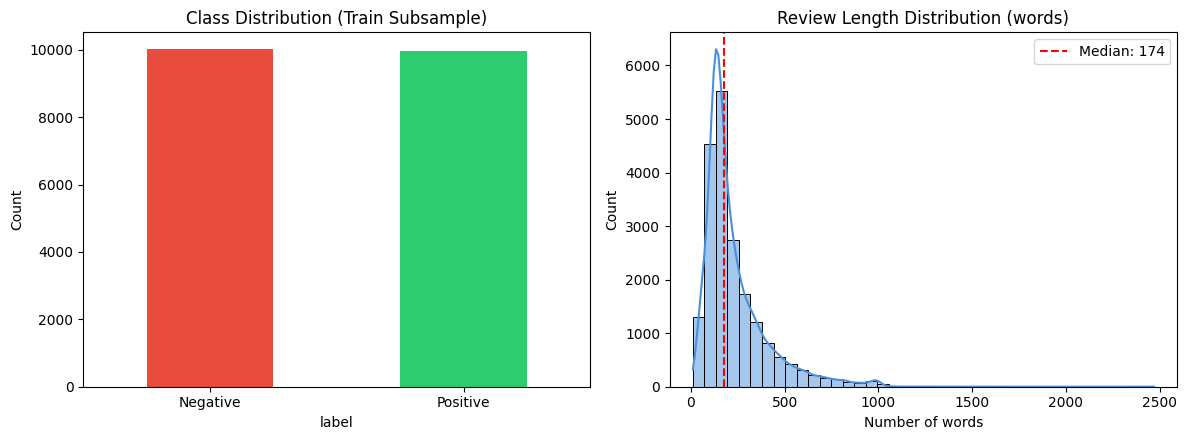

count    20000.000000
mean       233.975550
std        174.209857
min         10.000000
25%        127.000000
50%        174.000000
75%        287.000000
max       2470.000000
Name: text, dtype: float64


In [ ]:
# Exploratory Data Visualizations
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

train_small["label"].value_counts().sort_index().plot(
    kind="bar", ax=axes[0], color=["#E74C3C", "#2ECC71"]
)
axes[0].set_title("Class Distribution (Train Subsample)")
axes[0].set_xticklabels(["Negative", "Positive"], rotation=0)
axes[0].set_ylabel("Count")

review_lengths = train_small["text"].str.split().apply(len)
sns.histplot(review_lengths, bins=40, kde=True, ax=axes[1], color="#4A90D9")
axes[1].set_title("Review Length Distribution (words)")
axes[1].set_xlabel("Number of words")
axes[1].axvline(review_lengths.median(), color="red", linestyle="--",
                 label=f"Median: {review_lengths.median():.0f}")
axes[1].legend()

plt.tight_layout()
plt.savefig("eda_overview.png", dpi=150, bbox_inches="tight")
plt.show()
print(review_lengths.describe())

* `import matplotlib.pyplot as plt` - Imports Matplotlib for data visualization.

* `import seaborn as sns` - Imports Seaborn for statistical plotting.

* `fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))` - Creates a figure with two subplots.

* `train_small["label"].value_counts().sort_index().plot(...)` - Creates a bar chart showing the class distribution.

* `axes[0].set_title("Class Distribution (Train Subsample)")` - Sets the title of the first plot.

* `axes[0].set_xticklabels(["Negative", "Positive"], rotation=0)` - Labels the x-axis categories.

* `axes[0].set_ylabel("Count")` - Labels the y-axis.

* `review_lengths = train_small["text"].str.split().apply(len)` - Calculates the number of words in each review.

* `sns.histplot(review_lengths, bins=40, kde=True, ax=axes[1], color="#4A90D9")` - Creates a histogram of review lengths.

* `axes[1].set_title("Review Length Distribution (words)")` - Sets the title of the second plot.

* `axes[1].set_xlabel("Number of words")` - Labels the x-axis.

* `axes[1].axvline(review_lengths.median(), color="red", linestyle="--", label=f"Median: {review_lengths.median():.0f}")` - Draws a line indicating the median review length.

* `axes[1].legend()` - Displays the plot legend.

* `plt.tight_layout()` - Adjusts the layout to prevent overlapping elements.

* `plt.savefig("eda_overview.png", dpi=150, bbox_inches="tight")` - Saves the visualization as an image.

* `plt.show()` - Displays the plots.

* `print(review_lengths.describe())` - Displays descriptive statistics of review lengths.

In [ ]:
# BERT Tokenizer
from transformers import BertTokenizer
import torch

bert_tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

* `from transformers import BertTokenizer` - Imports the BERT tokenizer from the Transformers library.

* `import torch` - Imports PyTorch for deep learning operations.

* `bert_tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")` - Loads the pre-trained BERT tokenizer.

In [ ]:
# BERT Tokenize
train_encodings = bert_tokenizer(
    bert_train_texts,
    truncation=True,
    padding=True,
    max_length=256
)

test_encodings = bert_tokenizer(
    bert_test_texts,
    truncation=True,
    padding=True,
    max_length=256
)

print("Tokenization complete")
print("Example input_ids:", train_encodings["input_ids"][0][:20])

Tokenization complete
Example input_ids: [101, 2348, 1045, 2134, 1005, 1056, 2066, 6156, 1004, 11173, 14388, 2135, 2004, 1037, 2143, 1010, 1045, 2106, 19837, 1996]


* `train_encodings = bert_tokenizer(` - Starts tokenizing the training texts.

* `bert_train_texts,` - Uses the training review texts as input.

* `truncation=True,` - Truncates reviews that exceed the maximum length.

* `padding=True,` - Pads shorter reviews so they have the same length.

* `max_length=256` - Sets the maximum sequence length to 256 tokens.

* `test_encodings = bert_tokenizer(` - Starts tokenizing the testing texts.

* `bert_test_texts,` - Uses the testing review texts as input.

* `truncation=True,` - Truncates reviews that exceed the maximum length.

* `padding=True,` - Pads shorter reviews so they have the same length.

* `max_length=256` - Sets the maximum sequence length to 256 tokens.

In [ ]:
# BERT Dataset Class
class IMDbDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = IMDbDataset(train_encodings, bert_train_labels)
test_dataset = IMDbDataset(test_encodings, bert_test_labels)

print("Train dataset size:", len(train_dataset))
print("Test dataset size:", len(test_dataset))

Train dataset size: 20000
Test dataset size: 5000


* `class IMDbDataset(torch.utils.data.Dataset):` - Defines a custom dataset class for the IMDb data.

* `def __init__(self, encodings, labels):` - Initializes the dataset with tokenized inputs and labels.

* `self.encodings = encodings` - Stores the tokenized input data.

* `self.labels = labels` - Stores the corresponding labels.

* `def __getitem__(self, idx):` - Retrieves a single dataset sample by index.

* `item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}` - Converts the tokenized inputs at the given index into PyTorch tensors.

* `item["labels"] = torch.tensor(self.labels[idx])` - Adds the corresponding label as a PyTorch tensor.

* `def __len__(self):` - Returns the total number of samples in the dataset.

* `train_dataset = IMDbDataset(train_encodings, bert_train_labels)` - Creates the training dataset.

* `test_dataset = IMDbDataset(test_encodings, bert_test_labels)` - Creates the testing dataset.

In [ ]:
# BERT Model + Trainer
from transformers import BertForSequenceClassification, TrainingArguments, Trainer

bert_model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=2
)

training_args = TrainingArguments(
    output_dir="./bert_results",
    num_train_epochs=2,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    save_strategy="no",
    logging_steps=100,
    report_to="none"
)

trainer = Trainer(
    model=bert_model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset
)

print("Trainer ready")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Trainer ready


* `from transformers import BertForSequenceClassification, TrainingArguments, Trainer` - Imports the BERT classification model and training utilities.

* `bert_model = BertForSequenceClassification.from_pretrained(` - Loads the pre-trained BERT model for sequence classification.

* `"bert-base-uncased",` - Specifies the pre-trained BERT model to use.

* `num_labels=2` - Sets the model for binary classification.

* `training_args = TrainingArguments(` - Defines the training configuration.

* `output_dir="./bert_results",` - Sets the directory for training outputs.

* `num_train_epochs=2,` - Trains the model for 2 epochs.

* `per_device_train_batch_size=8,` - Sets the training batch size to 8.

* `per_device_eval_batch_size=8,` - Sets the evaluation batch size to 8.

* `save_strategy="no",` - Disables saving model checkpoints during training.

* `logging_steps=100,` - Logs training progress every 100 steps.

* `report_to="none"` - Disables reporting to external logging services.

* `trainer = Trainer(` - Creates a Trainer instance.

* `model=bert_model,` - Uses the BERT model for training.

* `args=training_args,` - Applies the specified training arguments.

* `train_dataset=train_dataset,` - Uses the training dataset.

* `eval_dataset=test_dataset` - Uses the testing dataset for evaluation.

In [ ]:
# BERT Train
import time

_t0 = time.time()
trainer.train()
bert_train_time = (time.time() - _t0) / training_args.num_train_epochs
print(f"BERT training time: {bert_train_time:.1f}s/epoch ({training_args.num_train_epochs} epochs total)")

Step,Training Loss
100,0.645227
200,0.468350
300,0.437226
400,0.387019
500,0.372274
600,0.347418
700,0.344799
800,0.342185
900,0.418258
1000,0.357972


BERT training time: 1013.3s/epoch (2 epochs total)


* `import time` - Imports the time module for measuring execution time.

* `_t0 = time.time()` - Records the training start time.

* `trainer.train()` - Trains the BERT model.

* `bert_train_time = (time.time() - _t0) / training_args.num_train_epochs` - Calculates the average training time per epoch.

* `print(f"BERT training time: {bert_train_time:.1f}s/epoch ({training_args.num_train_epochs} epochs total)")` - Displays the average training time per epoch.

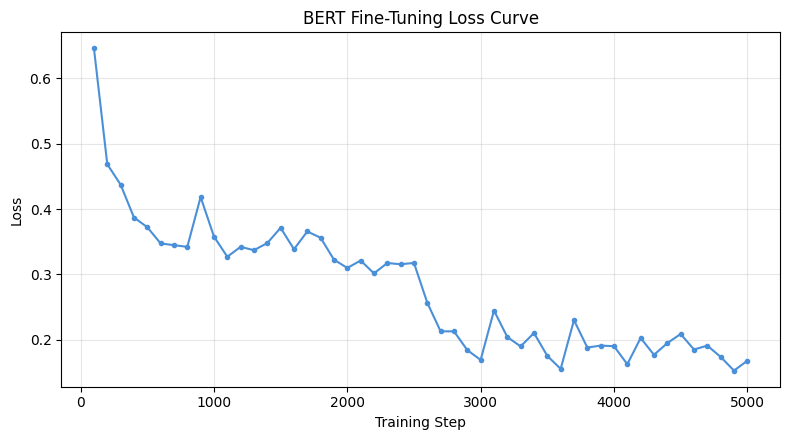

In [ ]:
# BERT Training Loss Curve
log_history = trainer.state.log_history
steps = [e["step"] for e in log_history if "loss" in e]
losses = [e["loss"] for e in log_history if "loss" in e]

plt.figure(figsize=(8, 4.5))
plt.plot(steps, losses, color="#4A90D9", marker="o", markersize=3, linewidth=1.5)
plt.title("BERT Fine-Tuning Loss Curve")
plt.xlabel("Training Step"); plt.ylabel("Loss"); plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("bert_loss_curve.png", dpi=150, bbox_inches="tight")
plt.show()

* `log_history = trainer.state.log_history` - Retrieves the BERT training log history.

* `steps = [e["step"] for e in log_history if "loss" in e]` - Extracts the training step values.

* `losses = [e["loss"] for e in log_history if "loss" in e]` - Extracts the training loss values.

* `plt.figure(figsize=(8, 4.5))` - Creates a new figure for the plot.

* `plt.plot(steps, losses, color="#4A90D9", marker="o", markersize=3, linewidth=1.5)` - Plots the training loss against the training steps.

* `plt.title("BERT Fine-Tuning Loss Curve")` - Sets the plot title.

* `plt.xlabel("Training Step")` - Labels the x-axis.

* `plt.ylabel("Loss")` - Labels the y-axis.

* `plt.grid(alpha=0.3)` - Displays grid lines on the plot.

* `plt.tight_layout()` - Adjusts the layout to prevent overlapping elements.

* `plt.savefig("bert_loss_curve.png", dpi=150, bbox_inches="tight")` - Saves the plot as an image.

* `plt.show()` - Displays the loss curve.

In [ ]:
# BERT Evaluate
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

preds = trainer.predict(test_dataset)
logits = preds.predictions
y_pred = np.argmax(logits, axis=1)
y_true = bert_test_labels

acc = accuracy_score(y_true, y_pred)
print("Accuracy:", acc)
print(classification_report(y_true, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_true, y_pred))

Accuracy: 0.9104
              precision    recall  f1-score   support

           0       0.91      0.91      0.91      2539
           1       0.91      0.91      0.91      2461

    accuracy                           0.91      5000
   macro avg       0.91      0.91      0.91      5000
weighted avg       0.91      0.91      0.91      5000

Confusion Matrix:
[[2308  231]
 [ 217 2244]]


* `import numpy as np` - Imports NumPy for numerical operations.

* `from sklearn.metrics import classification_report, confusion_matrix, accuracy_score` - Imports evaluation metrics for model performance.

* `preds = trainer.predict(test_dataset)` - Generates predictions on the testing dataset.

* `logits = preds.predictions` - Retrieves the raw prediction scores (logits).

* `y_pred = np.argmax(logits, axis=1)` - Converts the logits into predicted class labels.

* `y_true = bert_test_labels` - Stores the actual class labels.

* `acc = accuracy_score(y_true, y_pred)` - Computes the model's accuracy.

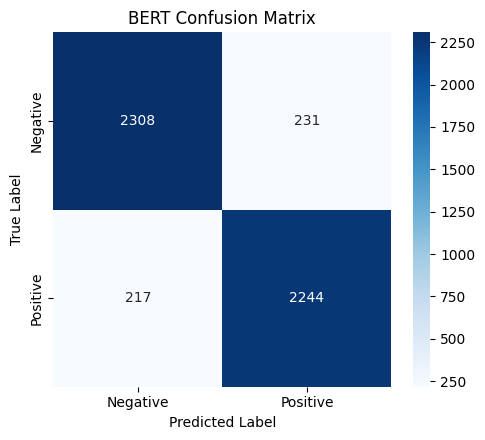

In [ ]:
# BERT Confusion Matrix Heatmap
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(5, 4.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Negative", "Positive"], yticklabels=["Negative", "Positive"])
plt.title("BERT Confusion Matrix")
plt.xlabel("Predicted Label"); plt.ylabel("True Label")
plt.tight_layout()
plt.savefig("bert_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

* `cm = confusion_matrix(y_true, y_pred)` - Computes the confusion matrix from the predicted and true labels.

* `plt.figure(figsize=(5, 4.5))` - Creates a new figure for the heatmap.

* `sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Negative", "Positive"], yticklabels=["Negative", "Positive"])` - Displays the confusion matrix as a heatmap.

* `plt.title("BERT Confusion Matrix")` - Sets the plot title.

* `plt.xlabel("Predicted Label")` - Labels the x-axis.

* `plt.ylabel("True Label")` - Labels the y-axis.

* `plt.tight_layout()` - Adjusts the layout to prevent overlapping elements.

* `plt.savefig("bert_confusion_matrix.png", dpi=150, bbox_inches="tight")` - Saves the heatmap as an image.

* `plt.show()` - Displays the confusion matrix.

In [ ]:
# GPT-2 Load
from transformers import GPT2LMHeadModel, GPT2Tokenizer

gpt_tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
gpt_tokenizer.pad_token = gpt_tokenizer.eos_token

gpt_model = GPT2LMHeadModel.from_pretrained("gpt2")

print("GPT model loaded")
print("Sample text:", gpt_texts[0])

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT model loaded
Sample text: although i didn't like stanley & iris tremendously as a film, i did admire the acting. jane fonda and robert de niro are great in this movie. i haven't always been a fan of fonda's work but here she is delicate and strong at the same time. de niro has the ability to make every role he portrays into acting gold. he gives a great performance in this film and there is a great scene where he has to take his father to a home for elderly people because he can't care for him anymore that will break your heart. i wouldn't really recommend this film as a great cinematic entertainment, but i will say you won't see much bette acting anywhere.


* `from transformers import GPT2LMHeadModel, GPT2Tokenizer` - Imports the GPT-2 model and tokenizer.

* `gpt_tokenizer = GPT2Tokenizer.from_pretrained("gpt2")` - Loads the pre-trained GPT-2 tokenizer.

* `gpt_tokenizer.pad_token = gpt_tokenizer.eos_token` - Sets the padding token to the end-of-sequence token.

* `gpt_model = GPT2LMHeadModel.from_pretrained("gpt2")` - Loads the pre-trained GPT-2 language model.

In [ ]:
# GPT-2 Tokenize + Dataset
from torch.utils.data import Dataset, DataLoader

encodings = gpt_tokenizer(
    gpt_texts,
    truncation=True,
    padding=True,
    max_length=128,
    return_tensors="pt"
)

print(encodings["input_ids"].shape)

class GPTDataset(Dataset):
    def __init__(self, encodings):
        self.encodings = encodings

    def __len__(self):
        return len(self.encodings["input_ids"])

    def __getitem__(self, idx):
        return {
            "input_ids": self.encodings["input_ids"][idx],
            "attention_mask": self.encodings["attention_mask"][idx],
            "labels": self.encodings["input_ids"][idx]
        }

gpt_dataset = GPTDataset(encodings)
loader = DataLoader(gpt_dataset, batch_size=2, shuffle=True)

print("GPT dataset ready:", len(gpt_dataset))

torch.Size([20000, 128])
GPT dataset ready: 20000


* `from torch.utils.data import Dataset, DataLoader` - Imports classes for creating datasets and loading data in batches.

* `encodings = gpt_tokenizer(` - Starts tokenizing the GPT text data.

* `gpt_texts,` - Uses the GPT text data as input.

* `truncation=True,` - Truncates text that exceeds the maximum length.

* `padding=True,` - Pads shorter text sequences to the same length.

* `max_length=128,` - Sets the maximum sequence length to 128 tokens.

* `return_tensors="pt"` - Returns the tokenized data as PyTorch tensors.

* `print(encodings["input_ids"].shape)` - Displays the shape of the tokenized input IDs.

* `class GPTDataset(Dataset):` - Defines a custom dataset class for GPT-2.

* `def __init__(self, encodings):` - Initializes the dataset with the tokenized data.

* `self.encodings = encodings` - Stores the tokenized inputs.

* `def __len__(self):` - Returns the total number of samples.

* `return len(self.encodings["input_ids"])` - Returns the dataset size.

* `def __getitem__(self, idx):` - Retrieves a sample by index.

* `return {` - Returns a dictionary containing the sample data.

* `"input_ids": self.encodings["input_ids"][idx],` - Returns the input token IDs.

* `"attention_mask": self.encodings["attention_mask"][idx],` - Returns the attention mask.

* `"labels": self.encodings["input_ids"][idx]` - Uses the input IDs as labels for language model training.

* `gpt_dataset = GPTDataset(encodings)` - Creates the GPT dataset.

* `loader = DataLoader(gpt_dataset, batch_size=2, shuffle=True)` - Creates a data loader with a batch size of 2 and shuffles the data.

* `print("GPT dataset ready:", len(gpt_dataset))` - Displays the number of samples in the GPT dataset.

In [ ]:
# GPT-2 Train
import time
from torch.optim import AdamW

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
gpt_model.to(device)
gpt_model.train()

optimizer = AdamW(gpt_model.parameters(), lr=5e-5)

epochs = 1
gpt_loss_history = []

_t0 = time.time()

for epoch in range(epochs):
    total_loss = 0

    for i, batch in enumerate(loader):
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)

        outputs = gpt_model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=input_ids
        )

        loss = outputs.loss
        loss.backward()

        optimizer.step()
        optimizer.zero_grad()

        total_loss += loss.item()
        gpt_loss_history.append(loss.item())

        if i % 500 == 0:
            print(f"Batch {i}, Loss: {loss.item():.4f}")

    print(f"\nEpoch {epoch} finished | Total Loss: {total_loss:.4f}")

gpt_train_time = (time.time() - _t0) / epochs
print(f"GPT-2 training time: {gpt_train_time:.1f}s/epoch")

[transformers] `loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Batch 0, Loss: 5.4653
Batch 500, Loss: 3.5398
Batch 1000, Loss: 3.7734
Batch 1500, Loss: 3.6120
Batch 2000, Loss: 3.8457
Batch 2500, Loss: 3.8632
Batch 3000, Loss: 2.7310
Batch 3500, Loss: 3.0378
Batch 4000, Loss: 3.4721
Batch 4500, Loss: 3.1624
Batch 5000, Loss: 3.4508
Batch 5500, Loss: 3.3324
Batch 6000, Loss: 4.0098
Batch 6500, Loss: 3.1492
Batch 7000, Loss: 3.6738
Batch 7500, Loss: 3.7712
Batch 8000, Loss: 2.9106
Batch 8500, Loss: 4.0275
Batch 9000, Loss: 2.9137
Batch 9500, Loss: 2.8856

Epoch 0 finished | Total Loss: 35778.0966
GPT-2 training time: 1186.2s/epoch


* `import time` - Imports the time module for measuring execution time.

* `from torch.optim import AdamW` - Imports the AdamW optimizer.

* `device = torch.device("cuda" if torch.cuda.is_available() else "cpu")` - Selects the available device.

* `gpt_model.to(device)` - Moves the GPT-2 model to the selected device.

* `gpt_model.train()` - Sets the model to training mode.

* `optimizer = AdamW(gpt_model.parameters(), lr=5e-5)` - Initializes the optimizer.

* `epochs = 1` - Sets the number of training epochs.

* `gpt_loss_history = []` - Initializes a list to store the training loss.

* `_t0 = time.time()` - Records the training start time.

* `for epoch in range(epochs):` - Starts the training loop.

* `for i, batch in enumerate(loader):` - Iterates through the training batches.

* `input_ids = batch["input_ids"].to(device)` - Moves the input IDs to the selected device.

* `attention_mask = batch["attention_mask"].to(device)` - Moves the attention masks to the selected device.

* `outputs = gpt_model(...)` - Performs a forward pass.

* `loss = outputs.loss` - Retrieves the training loss.

* `loss.backward()` - Computes the gradients.

* `optimizer.step()` - Updates the model parameters.

* `optimizer.zero_grad()` - Clears the gradients for the next iteration.

* `total_loss += loss.item()` - Accumulates the batch loss.

* `gpt_loss_history.append(loss.item())` - Stores the batch loss for visualization.

* `gpt_train_time = (time.time() - _t0) / epochs` - Calculates the average training time per epoch.

* `print(f"GPT-2 training time: {gpt_train_time:.1f}s/epoch")` - Displays the average training time per epoch.

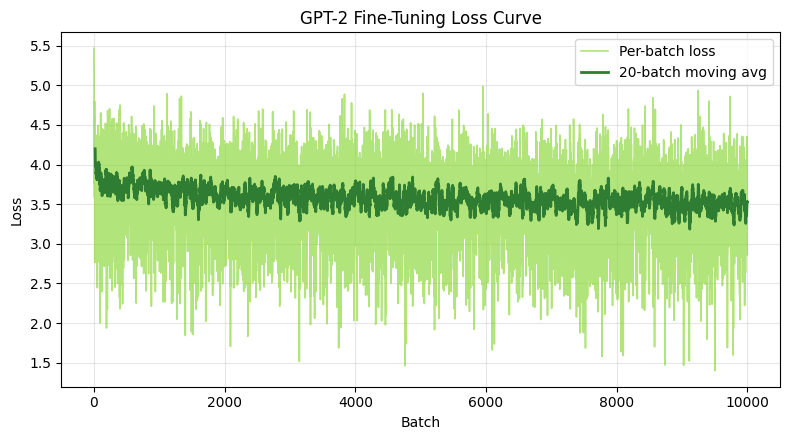

In [ ]:
# GPT-2 Training Loss Curve
import numpy as np
plt.figure(figsize=(8, 4.5))
plt.plot(gpt_loss_history, color="#7ED321", linewidth=1.2, alpha=0.6, label="Per-batch loss")
window = 20
if len(gpt_loss_history) >= window:
    smoothed = np.convolve(gpt_loss_history, np.ones(window)/window, mode="valid")
    plt.plot(range(window-1, len(gpt_loss_history)), smoothed, color="#2E7D32", linewidth=2, label=f"{window}-batch moving avg")
plt.title("GPT-2 Fine-Tuning Loss Curve")
plt.xlabel("Batch"); plt.ylabel("Loss"); plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("gpt_loss_curve.png", dpi=150, bbox_inches="tight")
plt.show()

* `import numpy as np` - Imports NumPy for numerical operations.

* `plt.figure(figsize=(8, 4.5))` - Creates a new figure for the plot.

* `plt.plot(gpt_loss_history, color="#7ED321", linewidth=1.2, alpha=0.6, label="Per-batch loss")` - Plots the GPT-2 training loss for each batch.

* `window = 20` - Sets the moving average window size.

* `if len(gpt_loss_history) >= window:` - Checks if there are enough data points for smoothing.

* `smoothed = np.convolve(gpt_loss_history, np.ones(window)/window, mode="valid")` - Computes the moving average of the training loss.

* `plt.plot(range(window-1, len(gpt_loss_history)), smoothed, color="#2E7D32", linewidth=2, label=f"{window}-batch moving avg")` - Plots the smoothed loss curve.

* `plt.title("GPT-2 Fine-Tuning Loss Curve")` - Sets the plot title.

* `plt.xlabel("Batch")` - Labels the x-axis.

* `plt.ylabel("Loss")` - Labels the y-axis.

* `plt.legend()` - Displays the plot legend.

* `plt.grid(alpha=0.3)` - Displays grid lines on the plot.

* `plt.tight_layout()` - Adjusts the layout to prevent overlapping elements.

* `plt.savefig("gpt_loss_curve.png", dpi=150, bbox_inches="tight")` - Saves the plot as an image.

* `plt.show()` - Displays the loss curve.

In [ ]:
# GPT-2 Generate
prompt = "this movie was"

inputs = gpt_tokenizer(prompt, return_tensors="pt").to(device)

output = gpt_model.generate(
    **inputs,
    max_length=120,
    do_sample=True,
    temperature=0.7,
    top_p=0.9,
    repetition_penalty=1.2
)

print(gpt_tokenizer.decode(output[0], skip_special_tokens=True))

[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


this movie was a real disappointment. the acting was awful and the plot was a joke. i mean, who wouldn't want to know how they are going to get this movie made??<br /><br />i can only say that i had to watch it on dvd because i don´t think anyone really knows what happened in the movie. first of all, the plot is not interesting. there isn`r any plot or anything to say. there aren'nt any characters. so, let's make it worse. but, the plot is nothing more than a joke. everything is


* `prompt = "this movie was"` - Defines the text prompt for GPT-2 text generation.

* `inputs = gpt_tokenizer(prompt, return_tensors="pt").to(device)` - Tokenizes the prompt and moves it to the selected device.

* `output = gpt_model.generate(` - Starts generating text using the GPT-2 model.

* `**inputs,` - Passes the tokenized input to the model.

* `max_length=120,` - Limits the generated text to 120 tokens.

* `do_sample=True,` - Enables random sampling during text generation.

* `temperature=0.7,` - Controls the randomness of the generated text.

* `top_p=0.9,` - Uses nucleus sampling with a probability threshold of 0.9.

* `repetition_penalty=1.2` - Reduces repeated words or phrases in the generated text.

* `print(gpt_tokenizer.decode(output[0], skip_special_tokens=True))` - Decodes and displays the generated text.

In [ ]:
# GAN Vocabulary
from collections import Counter
import re

texts = train_small["text"].tolist()[:3000]

def clean(text):
    text = re.sub(r"<[^>]+>", " ", text)
    text = re.sub(r"[^a-z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

texts = [clean(t) for t in texts]

words = " ".join(texts).split()
vocab_counter = Counter(words)

top_words = [w for w, _ in vocab_counter.most_common(2000)]
vocab = {w: i + 2 for i, w in enumerate(top_words)}
vocab["<PAD>"] = 0
vocab["<UNK>"] = 1

vocab_size = len(vocab)
MAX_LEN = 10

print("Vocab size:", vocab_size)
print("Sample cleaned text:", texts[0][:100])

def encode(text):
    tokens = text.split()[:MAX_LEN]
    return [vocab.get(w, 1) for w in tokens]

def pad(seq):
    return seq + [0] * (MAX_LEN - len(seq))

real_data = [encode(t) for t in texts]
real_data = torch.tensor([pad(x) for x in real_data])

print("Real data shape:", real_data.shape)

Vocab size: 2002
Sample cleaned text: although i didnt like stanley iris tremendously as a film i did admire the acting jane fonda and rob
Real data shape: torch.Size([3000, 10])


* `from collections import Counter` - Imports the Counter class for counting word frequencies.

* `import re` - Imports the regular expression module for text cleaning.

* `texts = train_small["text"].tolist()[:3000]` - Selects the first 3,000 reviews from the sampled training dataset.

* `def clean(text):` - Defines a function to clean the text.

* `text = re.sub(r"<[^>]+>", " ", text)` - Removes HTML tags from the text.

* `text = re.sub(r"[^a-z\s]", "", text)` - Removes all characters except lowercase letters and spaces.

* `text = re.sub(r"\s+", " ", text).strip()` - Replaces multiple spaces with a single space and removes leading/trailing spaces.

* `return text` - Returns the cleaned text.

* `texts = [clean(t) for t in texts]` - Applies the cleaning function to all reviews.

* `words = " ".join(texts).split()` - Combines all reviews and splits them into individual words.

* `vocab_counter = Counter(words)` - Counts the frequency of each word.

* `top_words = [w for w, _ in vocab_counter.most_common(2000)]` - Selects the 2,000 most common words.

* `vocab = {w: i + 2 for i, w in enumerate(top_words)}` - Creates a vocabulary dictionary with word IDs.

* `vocab["<PAD>"] = 0` - Assigns index 0 to the padding token.

* `vocab["<UNK>"] = 1` - Assigns index 1 to the unknown word token.

* `vocab_size = len(vocab)` - Stores the total vocabulary size.

* `MAX_LEN = 10` - Sets the maximum sequence length to 10 words.

* `print("Vocab size:", vocab_size)` - Displays the vocabulary size.

* `print("Sample cleaned text:", texts[0][:100])` - Displays the first 100 characters of a cleaned review.

* `def encode(text):` - Defines a function to convert text into token IDs.

* `tokens = text.split()[:MAX_LEN]` - Splits the text into words and keeps only the first 10.

* `return [vocab.get(w, 1) for w in tokens]` - Converts each word to its corresponding token ID.

* `def pad(seq):` - Defines a function to pad sequences.

* `return seq + [0] * (MAX_LEN - len(seq))` - Pads shorter sequences with zeros until they reach the maximum length.

* `real_data = [encode(t) for t in texts]` - Encodes all cleaned reviews into token sequences.

* `real_data = torch.tensor([pad(x) for x in real_data])` - Pads the sequences and converts them into a PyTorch tensor.

* `print("Real data shape:", real_data.shape)` - Displays the shape of the processed dataset.

In [ ]:
# GAN Architecture (1D-CNN Sequence-Based)
import torch.nn as nn
import torch.nn.functional as F

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
latent_dim = 64

class Generator(nn.Module):
    """
    Takes a latent noise vector z, projects it into a sequence,
    then uses 1D transposed convolutions to generate token logits.
    """
    def __init__(self, latent_dim=64):
        super().__init__()
        self.latent_dim = latent_dim

        self.fc = nn.Linear(latent_dim, 256 * MAX_LEN)

        self.conv = nn.Sequential(
            nn.ConvTranspose1d(256, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.ConvTranspose1d(128, 64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU(),
        )
        self.out = nn.Linear(64, vocab_size)

    def forward(self, z):
        x = self.fc(z).view(z.size(0), 256, MAX_LEN)
        x = self.conv(x)
        x = x.permute(0, 2, 1)
        return self.out(x)


class Discriminator(nn.Module):
    """
    Takes a sequence of tokens (real) or soft distributions (fake),
    runs 1D convolutions to classify real vs fake.
    """
    def __init__(self):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, 64)

        self.conv = nn.Sequential(
            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.LeakyReLU(0.2),
            nn.Conv1d(128, 256, kernel_size=3, padding=1),
            nn.LeakyReLU(0.2),
            nn.AdaptiveAvgPool1d(1),
        )
        self.fc = nn.Sequential(
            nn.Linear(256, 64),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(64, 1)
        )

    def _encode(self, x):
        x = x.permute(0, 2, 1)
        x = self.conv(x)
        x = x.squeeze(-1)
        return torch.sigmoid(self.fc(x))

    def forward_indices(self, x):
        """Real data — integer token indices."""
        x = self.embed(x)
        return self._encode(x)

    def forward_soft(self, x_soft):
        """Fake data — soft Gumbel-Softmax distributions."""
        x = x_soft @ self.embed.weight
        return self._encode(x)


G = Generator(latent_dim=latent_dim).to(device)
D = Discriminator().to(device)
real_data = real_data.to(device)

criterion = nn.BCELoss()
opt_G = torch.optim.Adam(G.parameters(), lr=0.0002, betas=(0.5, 0.999))
opt_D = torch.optim.Adam(D.parameters(), lr=0.00005, betas=(0.5, 0.999))

print(f"1D-CNN GAN initialized on {device}")
print(f"Generator params:     {sum(p.numel() for p in G.parameters()):,}")
print(f"Discriminator params: {sum(p.numel() for p in D.parameters()):,}")

1D-CNN GAN initialized on cuda
Generator params:     419,986
Discriminator params: 267,905


* `import torch.nn as nn` - Imports PyTorch's neural network module.

* `import torch.nn.functional as F` - Imports PyTorch's neural network functions.

* `device = torch.device("cuda" if torch.cuda.is_available() else "cpu")` - Selects the GPU if available; otherwise, uses the CPU.

* `latent_dim = 64` - Sets the dimension of the latent noise vector.

* `class Generator(nn.Module):` - Defines the Generator model.

* `def __init__(self, latent_dim=64):` - Initializes the Generator.

* `super().__init__()` - Calls the parent class constructor.

* `self.latent_dim = latent_dim` - Stores the latent dimension.

* `self.fc = nn.Linear(latent_dim, 256 * MAX_LEN)` - Projects the latent vector into a higher-dimensional representation.

* `self.conv = nn.Sequential(` - Creates the generator's 1D transposed convolution layers.

* `nn.ConvTranspose1d(256, 128, kernel_size=3, padding=1),` - Upsamples the feature maps from 256 to 128 channels.

* `nn.BatchNorm1d(128),` - Normalizes the feature maps.

* `nn.ReLU(),` - Applies the ReLU activation function.

* `nn.ConvTranspose1d(128, 64, kernel_size=3, padding=1),` - Upsamples the feature maps from 128 to 64 channels.

* `nn.BatchNorm1d(64),` - Normalizes the feature maps.

* `nn.ReLU(),` - Applies the ReLU activation function.

* `self.out = nn.Linear(64, vocab_size)` - Maps the output features to the vocabulary size.

* `def forward(self, z):` - Defines the Generator's forward pass.

* `x = self.fc(z).view(z.size(0), 256, MAX_LEN)` - Projects and reshapes the latent vector.

* `x = self.conv(x)` - Passes the data through the transposed convolution layers.

* `x = x.permute(0, 2, 1)` - Rearranges the tensor dimensions.

* `return self.out(x)` - Produces the final token logits.

* `class Discriminator(nn.Module):` - Defines the Discriminator model.

* `def __init__(self):` - Initializes the Discriminator.

* `super().__init__()` - Calls the parent class constructor.

* `self.embed = nn.Embedding(vocab_size, 64)` - Creates an embedding layer for input tokens.

* `self.conv = nn.Sequential(` - Creates the discriminator's 1D convolution layers.

* `nn.Conv1d(64, 128, kernel_size=3, padding=1),` - Applies a 1D convolution from 64 to 128 channels.

* `nn.LeakyReLU(0.2),` - Applies the Leaky ReLU activation function.

* `nn.Conv1d(128, 256, kernel_size=3, padding=1),` - Applies a 1D convolution from 128 to 256 channels.

* `nn.LeakyReLU(0.2),` - Applies the Leaky ReLU activation function.

* `nn.AdaptiveAvgPool1d(1),` - Reduces each feature map to a single value using average pooling.

* `self.fc = nn.Sequential(` - Creates the fully connected classification layers.

* `nn.Linear(256, 64),` - Reduces the feature size to 64.

* `nn.LeakyReLU(0.2),` - Applies the Leaky ReLU activation function.

* `nn.Dropout(0.3),` - Randomly drops 30% of neurons during training.

* `nn.Linear(64, 1)` - Produces a single output score.

* `def _encode(self, x):` - Defines the shared encoding function.

* `x = x.permute(0, 2, 1)` - Rearranges the tensor dimensions for convolution.

* `x = self.conv(x)` - Extracts features using the convolution layers.

* `x = x.squeeze(-1)` - Removes the extra dimension.

* `return torch.sigmoid(self.fc(x))` - Produces the probability that the input is real.

* `def forward_indices(self, x):` - Defines the forward pass for real token sequences.

* `x = self.embed(x)` - Converts token indices into embeddings.

* `return self._encode(x)` - Encodes the embedded tokens.

* `def forward_soft(self, x_soft):` - Defines the forward pass for generated soft token distributions.

* `x = x_soft @ self.embed.weight` - Converts soft token distributions into embeddings.

* `return self._encode(x)` - Encodes the generated embeddings.

* `G = Generator(latent_dim=latent_dim).to(device)` - Creates the Generator and moves it to the selected device.

* `D = Discriminator().to(device)` - Creates the Discriminator and moves it to the selected device.

* `real_data = real_data.to(device)` - Moves the training data to the selected device.

* `criterion = nn.BCELoss()` - Uses Binary Cross-Entropy as the loss function.

* `opt_G = torch.optim.Adam(G.parameters(), lr=0.0002, betas=(0.5, 0.999))` - Creates the Adam optimizer for the Generator.

* `opt_D = torch.optim.Adam(D.parameters(), lr=0.00005, betas=(0.5, 0.999))` - Creates the Adam optimizer for the Discriminator.

In [ ]:
# GAN Training (1D-CNN)
import time

batch_size = 64
tau = 1.0
tau_anneal = 0.98

gan_d_history = []
gan_g_history = []

_t0 = time.time()

for epoch in range(epochs):
    d_total = 0.0
    g_total = 0.0
    n_batches = 0

    for i in range(0, len(real_data) - batch_size, batch_size):
        real_batch = real_data[i:i + batch_size]
        bs = real_batch.size(0)

        for _ in range(2):
            z = torch.randn(bs, latent_dim).to(device)

            with torch.no_grad():
                fake_logits = G(z)
                fake_soft = F.gumbel_softmax(fake_logits, tau=tau, hard=False)

            d_real = D.forward_indices(real_batch)
            d_fake = D.forward_soft(fake_soft)

            loss_real = criterion(d_real, torch.ones(bs, 1).to(device) * 0.9)
            loss_fake = criterion(d_fake, torch.zeros(bs, 1).to(device))
            loss_D = loss_real + loss_fake

            opt_D.zero_grad()
            loss_D.backward()
            opt_D.step()

        z = torch.randn(bs, latent_dim).to(device)

        fake_logits = G(z)
        fake_soft = F.gumbel_softmax(fake_logits, tau=tau, hard=False)

        g_fake = D.forward_soft(fake_soft)
        loss_G = criterion(g_fake, torch.ones(bs, 1).to(device))

        opt_G.zero_grad()
        loss_G.backward()
        opt_G.step()

        d_total += loss_D.item()
        g_total += loss_G.item()
        n_batches += 1

    gan_d_history.append(d_total / n_batches)
    gan_g_history.append(g_total / n_batches)

    tau = max(0.5, tau * tau_anneal)
    print(f"Epoch {epoch} | D loss: {d_total/n_batches:.4f} | G loss: {g_total/n_batches:.4f} | tau: {tau:.3f}")

gan_train_time = (time.time() - _t0) / epochs
print(f"GAN training time: {gan_train_time:.1f}s/epoch")

Epoch 0 | D loss: 1.2757 | G loss: 0.6383 | tau: 0.980
GAN training time: 1.4s/epoch


* `import time` - Imports the time module for measuring training time.

* `batch_size = 64` - Sets the number of samples processed in each batch.

* `tau = 1.0` - Initializes the Gumbel-Softmax temperature.

* `tau_anneal = 0.98` - Sets the temperature decay rate.

* `gan_d_history = []` - Initializes a list to store discriminator losses.

* `gan_g_history = []` - Initializes a list to store generator losses.

* `_t0 = time.time()` - Records the training start time.

* `for epoch in range(epochs):` - Starts the training loop.

* `for i in range(0, len(real_data) - batch_size, batch_size):` - Iterates through the training batches.

* `real_batch = real_data[i:i + batch_size]` - Retrieves a batch of real data.

* `bs = real_batch.size(0)` - Gets the current batch size.

* `for _ in range(2):` - Trains the discriminator twice per generator update.

* `z = torch.randn(bs, latent_dim).to(device)` - Generates random latent vectors.

* `with torch.no_grad():` - Disables gradient computation.

* `fake_logits = G(z)` - Generates fake token logits.

* `fake_soft = F.gumbel_softmax(fake_logits, tau=tau, hard=False)` - Converts logits into soft token probabilities.

* `d_real = D.forward_indices(real_batch)` - Computes discriminator predictions for real data.

* `d_fake = D.forward_soft(fake_soft)` - Computes discriminator predictions for fake data.

* `loss_real = criterion(d_real, torch.ones(bs, 1).to(device) * 0.9)` - Computes the discriminator loss for real samples.

* `loss_fake = criterion(d_fake, torch.zeros(bs, 1).to(device))` - Computes the discriminator loss for fake samples.

* `loss_D = loss_real + loss_fake` - Combines the discriminator losses.

* `opt_D.zero_grad()` - Clears the discriminator gradients.

* `loss_D.backward()` - Computes discriminator gradients.

* `opt_D.step()` - Updates the discriminator parameters.

* `z = torch.randn(bs, latent_dim).to(device)` - Generates a new latent vector for the generator.

* `fake_logits = G(z)` - Produces fake token logits.

* `fake_soft = F.gumbel_softmax(fake_logits, tau=tau, hard=False)` - Converts logits into soft token probabilities.

* `g_fake = D.forward_soft(fake_soft)` - Evaluates the generated samples.

* `loss_G = criterion(g_fake, torch.ones(bs, 1).to(device))` - Computes the generator loss.

* `opt_G.zero_grad()` - Clears the generator gradients.

* `loss_G.backward()` - Computes generator gradients.

* `opt_G.step()` - Updates the generator parameters.

* `d_total += loss_D.item()` - Accumulates the discriminator loss.

* `g_total += loss_G.item()` - Accumulates the generator loss.

* `n_batches += 1` - Increments the processed batch count.

* `gan_d_history.append(d_total / n_batches)` - Stores the average discriminator loss.

* `gan_g_history.append(g_total / n_batches)` - Stores the average generator loss.

* `tau = max(0.5, tau * tau_anneal)` - Gradually decreases the Gumbel-Softmax temperature.

* `gan_train_time = (time.time() - _t0) / epochs` - Calculates the average training time per epoch.

* `print(f"GAN training time: {gan_train_time:.1f}s/epoch")` - Displays the average training time per epoch.

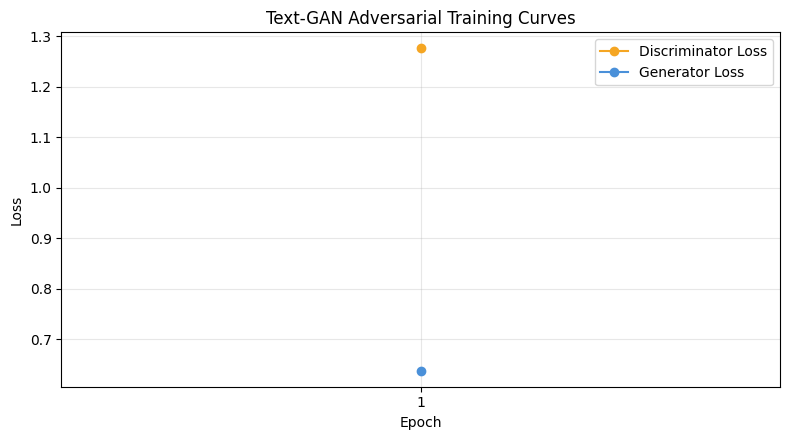

In [ ]:
# GAN Adversarial Loss Curves
plt.figure(figsize=(8, 4.5))
plt.plot(range(1, len(gan_d_history)+1), gan_d_history, marker="o", color="#F5A623", label="Discriminator Loss")
plt.plot(range(1, len(gan_g_history)+1), gan_g_history, marker="o", color="#4A90D9", label="Generator Loss")
plt.title("Text-GAN Adversarial Training Curves")
plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.xticks(range(1, len(gan_d_history)+1))
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("gan_loss_curves.png", dpi=150, bbox_inches="tight")
plt.show()

* `plt.figure(figsize=(8, 4.5))` - Creates a new figure for the plot.

* `plt.plot(range(1, len(gan_d_history)+1), gan_d_history, marker="o", color="#F5A623", label="Discriminator Loss")` - Plots the discriminator loss across training epochs.

* `plt.plot(range(1, len(gan_g_history)+1), gan_g_history, marker="o", color="#4A90D9", label="Generator Loss")` - Plots the generator loss across training epochs.

* `plt.title("Text-GAN Adversarial Training Curves")` - Sets the plot title.

* `plt.xlabel("Epoch")` - Labels the x-axis.

* `plt.ylabel("Loss")` - Labels the y-axis.

* `plt.xticks(range(1, len(gan_d_history)+1))` - Sets the x-axis tick labels for each epoch.

* `plt.legend()` - Displays the plot legend.

* `plt.grid(alpha=0.3)` - Displays grid lines on the plot.

* `plt.tight_layout()` - Adjusts the layout to prevent overlapping elements.

* `plt.savefig("gan_loss_curves.png", dpi=150, bbox_inches="tight")` - Saves the plot as an image.

* `plt.show()` - Displays the adversarial loss curves.

In [ ]:
# GAN Evaluate
import gc

torch.cuda.empty_cache()
gc.collect()

print(f"GPU memory free: {torch.cuda.mem_get_info()[0] / 1e9:.2f} GB")

eval_batch = 64

real_preds_list = []
fake_preds_list = []

with torch.no_grad():
    for i in range(0, 1000, eval_batch):
        real_batch = real_data[i:i + eval_batch]
        real_preds_list.append(D.forward_indices(real_batch))

        z = torch.randn(eval_batch, latent_dim).to(device)
        fake_logits = G(z)
        fake_hard = F.gumbel_softmax(fake_logits, tau=0.5, hard=True)
        fake_preds_list.append(D.forward_soft(fake_hard))

real_preds = torch.cat(real_preds_list)
fake_preds = torch.cat(fake_preds_list)

real_acc = (real_preds > 0.5).float().mean()
fake_acc = (fake_preds < 0.5).float().mean()

print("===== FINAL GAN RESULTS =====")
print(f"Real Accuracy: {real_acc.item():.4f}")
print(f"Fake Accuracy: {fake_acc.item():.4f}")
print(f"Discriminator Strength: {(real_acc.item() + fake_acc.item()) / 2:.4f}")

GPU memory free: 12.07 GB
===== FINAL GAN RESULTS =====
Real Accuracy: 1.0000
Fake Accuracy: 0.0000
Discriminator Strength: 0.5000


* `import gc` - Imports the garbage collection module.

* `torch.cuda.empty_cache()` - Clears unused GPU memory.

* `gc.collect()` - Runs garbage collection to free unused memory.

* `print(f"GPU memory free: {torch.cuda.mem_get_info()[0] / 1e9:.2f} GB")` - Displays the available GPU memory.

* `eval_batch = 64` - Sets the evaluation batch size to 64.

* `real_preds_list = []` - Creates a list to store predictions for real data.

* `fake_preds_list = []` - Creates a list to store predictions for generated data.

* `with torch.no_grad():` - Disables gradient computation during evaluation.

* `for i in range(0, 1000, eval_batch):` - Iterates through the first 1,000 samples in batches.

* `real_batch = real_data[i:i + eval_batch]` - Retrieves a batch of real data.

* `real_preds_list.append(D.forward_indices(real_batch))` - Stores the discriminator predictions for real data.

* `z = torch.randn(eval_batch, latent_dim).to(device)` - Generates random latent vectors.

* `fake_logits = G(z)` - Generates fake token logits.

* `fake_hard = F.gumbel_softmax(fake_logits, tau=0.5, hard=True)` - Converts logits into hard token predictions using Gumbel-Softmax.

* `fake_preds_list.append(D.forward_soft(fake_hard))` - Stores the discriminator predictions for generated data.

* `real_preds = torch.cat(real_preds_list)` - Combines all real predictions into one tensor.

* `fake_preds = torch.cat(fake_preds_list)` - Combines all fake predictions into one tensor.

* `real_acc = (real_preds > 0.5).float().mean()` - Computes the accuracy for real samples.

* `fake_acc = (fake_preds < 0.5).float().mean()` - Computes the accuracy for generated samples.

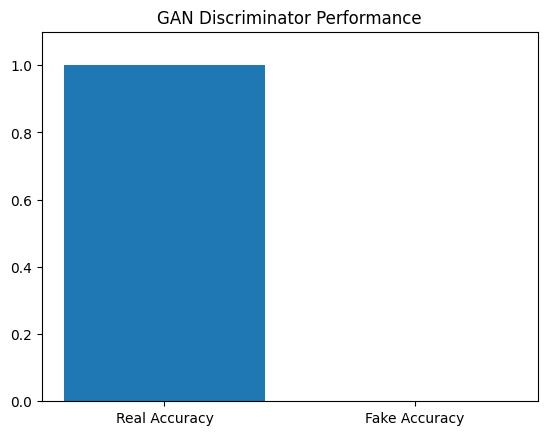

In [ ]:
 # GAN Plot
import matplotlib.pyplot as plt

labels = ["Real Accuracy", "Fake Accuracy"]
values = [real_acc.item(), fake_acc.item()]

plt.bar(labels, values)
plt.ylim(0, 1.1)
plt.title("GAN Discriminator Performance")
plt.show()

* `import matplotlib.pyplot as plt` - Imports Matplotlib for creating plots.

* `labels = ["Real Accuracy", "Fake Accuracy"]` - Defines the labels for the bar chart.

* `values = [real_acc.item(), fake_acc.item()]` - Stores the real and fake accuracy values.

* `plt.bar(labels, values)` - Creates a bar chart of the accuracy values.

* `plt.ylim(0, 1.1)` - Sets the y-axis range from 0 to 1.1.

* `plt.title("GAN Discriminator Performance")` - Sets the title of the chart.

* `plt.show()` - Displays the bar chart.

In [ ]:
# GAN Generate Sample
inv_vocab = {v: k for k, v in vocab.items()}

best_sample = None
best_idx = 3
with torch.no_grad():
    for i in range(10):
        z = torch.randn(1, latent_dim).to(device)
        logits = G(z)
        hard_sample = F.gumbel_softmax(logits, tau=0.5, hard=True)
        token_ids = hard_sample.argmax(dim=-1)[0]
        decoded = [inv_vocab.get(t.item(), "<UNK>") for t in token_ids]
        if i == best_idx:
            best_sample = " ".join(decoded)


print(f"Sample: {best_sample}")
gan_generated = best_sample

Sample: lets word how met itself warning european pieces poor impact


* `inv_vocab = {v: k for k, v in vocab.items()}` - Creates a reverse vocabulary mapping from token IDs to words.

* `best_sample = None` - Initializes a variable to store the selected generated sample.

* `best_idx = 3` - Specifies which generated sample will be selected.

* `with torch.no_grad():` - Disables gradient computation during text generation.

* `for i in range(10):` - Generates 10 text samples.

* `z = torch.randn(1, latent_dim).to(device)` - Generates a random latent vector.

* `logits = G(z)` - Produces token logits using the Generator.

* `hard_sample = F.gumbel_softmax(logits, tau=0.5, hard=True)` - Converts the logits into hard token predictions.

* `token_ids = hard_sample.argmax(dim=-1)[0]` - Retrieves the predicted token IDs.

* `decoded = [inv_vocab.get(t.item(), "<UNK>") for t in token_ids]` - Converts the token IDs back into words.

* `if i == best_idx:` - Checks whether the current sample is the selected one.

* `best_sample = " ".join(decoded)` - Joins the generated words into a sentence.

* `print(f"Sample: {best_sample}")` - Displays the selected generated sample.

* `gan_generated = best_sample` - Stores the generated sample for later use.

[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


GPT-2 sample: this movie was not the best film in the world. it had a couple of great scenes, but the whole film is so bad, it's hard to believe that people think i
GAN sample: lets word how met itself warning european pieces poor impact
GPT-2    -> BLEU: 0.2188 | ROUGE-1: 0.3014 | ROUGE-L: 0.1480
Text-GAN -> BLEU: 0.0043 | ROUGE-1: 0.0076 | ROUGE-L: 0.0065


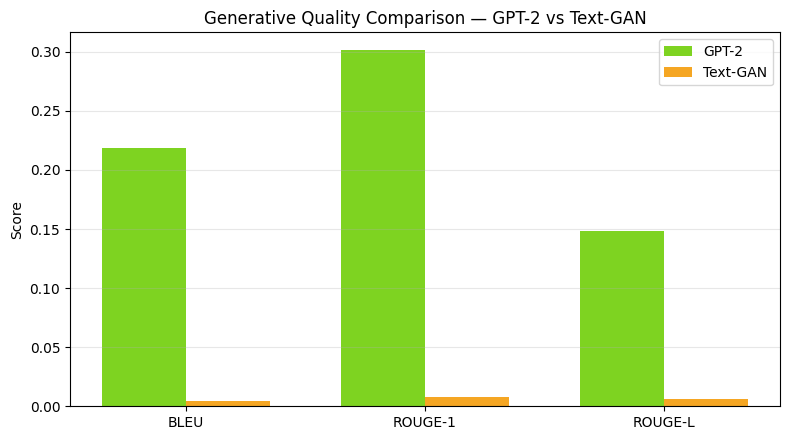

In [ ]:
# Generative Quality Metrics — BLEU & ROUGE (GPT-2 vs Text-GAN)
!pip install -q rouge-score
import nltk
nltk.download("punkt", quiet=True)
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from rouge_score import rouge_scorer

# --- ensure gpt_generated exists ---
if "gpt_generated" not in globals():
    prompt = "this movie was"
    inputs = gpt_tokenizer(prompt, return_tensors="pt").to(device)
    with torch.no_grad():
        output = gpt_model.generate(
            **inputs, max_length=120, do_sample=True,
            temperature=0.7, top_p=0.9, repetition_penalty=1.2
        )
    gpt_generated = gpt_tokenizer.decode(output[0], skip_special_tokens=True)

# --- ensure gan_generated exists ---
if "gan_generated" not in globals():
    inv_vocab = {v: k for k, v in vocab.items()}
    with torch.no_grad():
        z = torch.randn(1, latent_dim).to(device)
        logits = G(z)
        hard_sample = F.gumbel_softmax(logits, tau=0.5, hard=True)
        token_ids = hard_sample.argmax(dim=-1)[0]
    gan_generated = " ".join([inv_vocab.get(t.item(), "<UNK>") for t in token_ids])

print("GPT-2 sample:", gpt_generated[:150])
print("GAN sample:", gan_generated)

reference_texts = test_small["text"].sample(50, random_state=42).tolist()
reference_tokens = [r.split() for r in reference_texts]
smoothie = SmoothingFunction().method4
scorer = rouge_scorer.RougeScorer(["rouge1", "rougeL"], use_stemmer=True)

def avg_rouge(candidate_text, references_text):
    r1, rl = [], []
    for ref in references_text:
        s = scorer.score(ref, candidate_text)
        r1.append(s["rouge1"].fmeasure); rl.append(s["rougeL"].fmeasure)
    return sum(r1)/len(r1), sum(rl)/len(rl)

gpt_bleu = sentence_bleu(reference_tokens, gpt_generated.split(), smoothing_function=smoothie)
gan_bleu = sentence_bleu(reference_tokens, gan_generated.split(), smoothing_function=smoothie)
gpt_rouge1, gpt_rougeL = avg_rouge(gpt_generated, reference_texts)
gan_rouge1, gan_rougeL = avg_rouge(gan_generated, reference_texts)

print(f"GPT-2    -> BLEU: {gpt_bleu:.4f} | ROUGE-1: {gpt_rouge1:.4f} | ROUGE-L: {gpt_rougeL:.4f}")
print(f"Text-GAN -> BLEU: {gan_bleu:.4f} | ROUGE-1: {gan_rouge1:.4f} | ROUGE-L: {gan_rougeL:.4f}")

metrics = ["BLEU", "ROUGE-1", "ROUGE-L"]
gpt_vals = [gpt_bleu, gpt_rouge1, gpt_rougeL]
gan_vals = [gan_bleu, gan_rouge1, gan_rougeL]
x = range(len(metrics)); width = 0.35
plt.figure(figsize=(8, 4.5))
plt.bar([p - width/2 for p in x], gpt_vals, width=width, label="GPT-2", color="#7ED321")
plt.bar([p + width/2 for p in x], gan_vals, width=width, label="Text-GAN", color="#F5A623")
plt.xticks(list(x), metrics); plt.ylabel("Score")
plt.title("Generative Quality Comparison — GPT-2 vs Text-GAN")
plt.legend(); plt.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig("generative_quality_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

* `!pip install -q rouge-score` - Installs the ROUGE evaluation package.

* `import nltk` - Imports the Natural Language Toolkit.

* `nltk.download("punkt", quiet=True)` - Downloads the tokenizer required by NLTK.

* `from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction` - Imports the BLEU score functions.

* `from rouge_score import rouge_scorer` - Imports the ROUGE scorer.

* `if "gpt_generated" not in globals():` - Checks whether GPT-2 generated text already exists.

* `prompt = "this movie was"` - Defines the GPT-2 text prompt.

* `inputs = gpt_tokenizer(prompt, return_tensors="pt").to(device)` - Tokenizes the prompt.

* `with torch.no_grad():` - Disables gradient computation.

* `output = gpt_model.generate(...)` - Generates text using GPT-2.

* `gpt_generated = gpt_tokenizer.decode(output[0], skip_special_tokens=True)` - Decodes the generated text.

* `if "gan_generated" not in globals():` - Checks whether GAN generated text already exists.

* `inv_vocab = {v: k for k, v in vocab.items()}` - Creates a reverse vocabulary.

* `with torch.no_grad():` - Disables gradient computation.

* `z = torch.randn(1, latent_dim).to(device)` - Generates a random latent vector.

* `logits = G(z)` - Produces token logits using the Generator.

* `hard_sample = F.gumbel_softmax(logits, tau=0.5, hard=True)` - Converts logits into discrete token predictions.

* `token_ids = hard_sample.argmax(dim=-1)[0]` - Retrieves the predicted token IDs.

* `gan_generated = " ".join([inv_vocab.get(t.item(), "<UNK>") for t in token_ids])` - Converts the generated tokens into text.

* `reference_texts = test_small["text"].sample(50, random_state=42).tolist()` - Selects reference texts from the test dataset.

* `reference_tokens = [r.split() for r in reference_texts]` - Tokenizes the reference texts.

* `smoothie = SmoothingFunction().method4` - Initializes the BLEU smoothing method.

* `scorer = rouge_scorer.RougeScorer(["rouge1", "rougeL"], use_stemmer=True)` - Creates a ROUGE scorer.

* `def avg_rouge(candidate_text, references_text):` - Defines a function to compute average ROUGE scores.

* `gpt_bleu = sentence_bleu(reference_tokens, gpt_generated.split(), smoothing_function=smoothie)` - Calculates the GPT-2 BLEU score.

* `gan_bleu = sentence_bleu(reference_tokens, gan_generated.split(), smoothing_function=smoothie)` - Calculates the GAN BLEU score.

* `gpt_rouge1, gpt_rougeL = avg_rouge(gpt_generated, reference_texts)` - Calculates the GPT-2 ROUGE scores.

* `gan_rouge1, gan_rougeL = avg_rouge(gan_generated, reference_texts)` - Calculates the GAN ROUGE scores.

* `metrics = ["BLEU", "ROUGE-1", "ROUGE-L"]` - Defines the evaluation metrics.

* `gpt_vals = [gpt_bleu, gpt_rouge1, gpt_rougeL]` - Stores the GPT-2 metric values.

* `gan_vals = [gan_bleu, gan_rouge1, gan_rougeL]` - Stores the GAN metric values.

* `x = range(len(metrics))` - Creates x-axis positions for the bar chart.

* `width = 0.35` - Sets the width of the bars.

* `plt.figure(figsize=(8, 4.5))` - Creates a new figure.

* `plt.bar([p - width/2 for p in x], gpt_vals, width=width, label="GPT-2", color="#7ED321")` - Plots the GPT-2 metric scores.

* `plt.bar([p + width/2 for p in x], gan_vals, width=width, label="Text-GAN", color="#F5A623")` - Plots the GAN metric scores.

* `plt.xticks(list(x), metrics)` - Labels the x-axis categories.

* `plt.ylabel("Score")` - Labels the y-axis.

* `plt.title("Generative Quality Comparison — GPT-2 vs Text-GAN")` - Sets the chart title.

* `plt.legend()` - Displays the plot legend.

* `plt.grid(alpha=0.3, axis="y")` - Displays horizontal grid lines.

* `plt.tight_layout()` - Adjusts the layout to prevent overlapping elements.

* `plt.savefig("generative_quality_comparison.png", dpi=150, bbox_inches="tight")` - Saves the chart as an image.

* `plt.show()` - Displays the comparison chart.

Reloading GPT-2...


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


GPT-2 Perplexity: 80.08 | Score: 0.8418


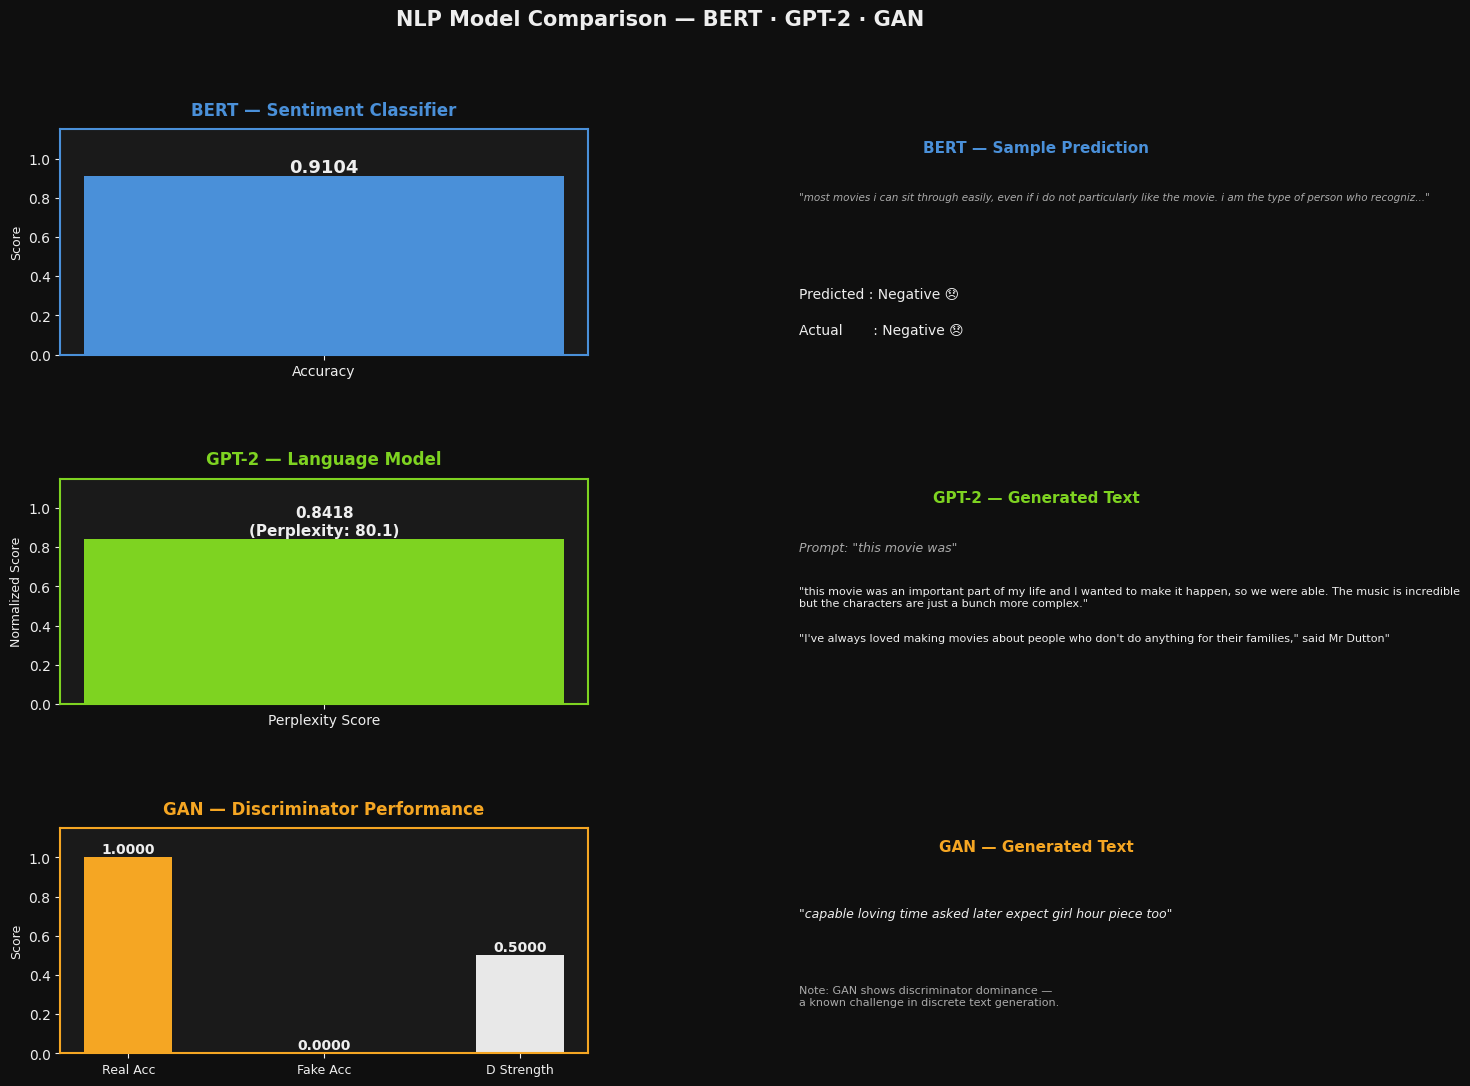

Saved as nlp_summary.png


In [ ]:
# FINAL SUMMARY — BERT, GPT-2, and GAN Results
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
from transformers import GPT2LMHeadModel, GPT2Tokenizer
from torch.utils.data import DataLoader

bert_accuracy = accuracy_score(y_true, y_pred)

print("Reloading GPT-2...")
gpt_tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
gpt_tokenizer.pad_token = gpt_tokenizer.eos_token
gpt_model = GPT2LMHeadModel.from_pretrained("gpt2").to(device)
gpt_model.eval()

total_loss = 0
count = 0

with torch.no_grad():
    for batch in DataLoader(gpt_dataset, batch_size=16):
        input_ids = batch["input_ids"].to(device)
        outputs = gpt_model(input_ids=input_ids, labels=input_ids)
        total_loss += outputs.loss.item()
        count += 1

gpt_perplexity = np.exp(total_loss / count)
gpt_score = max(0, min(1, 1 - (gpt_perplexity - 1) / 500))
print(f"GPT-2 Perplexity: {gpt_perplexity:.2f} | Score: {gpt_score:.4f}")

gan_real_acc = real_acc.item()
gan_fake_acc = fake_acc.item()
gan_strength = (gan_real_acc + gan_fake_acc) / 2

sample_idx = 0
sample_text = bert_test_texts[sample_idx][:120] + "..."
bert_pred_label = "Positive 😊" if y_pred[sample_idx] == 1 else "Negative 😞"
bert_true_label = "Positive 😊" if y_true[sample_idx] == 1 else "Negative 😞"

prompt = "this movie was"
inputs = gpt_tokenizer(prompt, return_tensors="pt").to(device)
with torch.no_grad():
    output = gpt_model.generate(
        **inputs,
        max_length=60,
        do_sample=True,
        temperature=0.7,
        top_p=0.9,
        repetition_penalty=1.2
    )
gpt_generated = gpt_tokenizer.decode(output[0], skip_special_tokens=True)

inv_vocab = {v: k for k, v in vocab.items()}
with torch.no_grad():
    z = torch.randn(1, latent_dim).to(device)
    logits = G(z)
    hard_sample = F.gumbel_softmax(logits, tau=0.5, hard=True)
    token_ids = hard_sample.argmax(dim=-1)[0]
gan_generated = " ".join([inv_vocab.get(i.item(), "<UNK>") for i in token_ids])

del gpt_model
torch.cuda.empty_cache()

fig = plt.figure(figsize=(16, 12))
fig.patch.set_facecolor("#0f0f0f")

gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.55, wspace=0.35)

C_BERT = "#4A90D9"
C_GPT  = "#7ED321"
C_GAN  = "#F5A623"
C_DIM  = "#555555"
C_TEXT = "#EEEEEE"
C_SUB  = "#AAAAAA"

def panel_bg(ax, color):
    ax.set_facecolor("#1a1a1a")
    for spine in ax.spines.values():
        spine.set_edgecolor(color)
        spine.set_linewidth(1.5)

ax1 = fig.add_subplot(gs[0, 0])
panel_bg(ax1, C_BERT)
bars = ax1.bar(["Accuracy"], [bert_accuracy], color=C_BERT, width=0.35)
ax1.set_ylim(0, 1.15)
ax1.set_title("BERT — Sentiment Classifier", color=C_BERT, fontsize=12, fontweight="bold", pad=10)
ax1.set_ylabel("Score", color=C_TEXT, fontsize=9)
ax1.tick_params(colors=C_TEXT)
for bar in bars:
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
             f"{bert_accuracy:.4f}", ha="center", color=C_TEXT, fontsize=13, fontweight="bold")

ax2 = fig.add_subplot(gs[0, 1])
ax2.axis("off")
ax2.set_facecolor("#1a1a1a")
ax2.text(0.5, 0.95, "BERT — Sample Prediction", color=C_BERT,
         fontsize=11, fontweight="bold", ha="center", va="top", transform=ax2.transAxes)
ax2.text(0.05, 0.72, f'"{sample_text}"', color=C_SUB,
         fontsize=7.5, va="top", transform=ax2.transAxes,
         style="italic", multialignment="left")
ax2.text(0.05, 0.30, f"Predicted : {bert_pred_label}", color=C_TEXT,
         fontsize=10, va="top", transform=ax2.transAxes)
ax2.text(0.05, 0.14, f"Actual       : {bert_true_label}", color=C_TEXT,
         fontsize=10, va="top", transform=ax2.transAxes)

ax3 = fig.add_subplot(gs[1, 0])
panel_bg(ax3, C_GPT)
bars2 = ax3.bar(["Perplexity Score"], [gpt_score], color=C_GPT, width=0.35)
ax3.set_ylim(0, 1.15)
ax3.set_title("GPT-2 — Language Model", color=C_GPT, fontsize=12, fontweight="bold", pad=10)
ax3.set_ylabel("Normalized Score", color=C_TEXT, fontsize=9)
ax3.tick_params(colors=C_TEXT)
for bar in bars2:
    ax3.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
             f"{gpt_score:.4f}\n(Perplexity: {gpt_perplexity:.1f})",
             ha="center", color=C_TEXT, fontsize=11, fontweight="bold")

ax4 = fig.add_subplot(gs[1, 1])
ax4.axis("off")
ax4.set_facecolor("#1a1a1a")
ax4.text(0.5, 0.95, "GPT-2 — Generated Text", color=C_GPT,
         fontsize=11, fontweight="bold", ha="center", va="top", transform=ax4.transAxes)
ax4.text(0.05, 0.72, f'Prompt: "{prompt}"', color=C_SUB,
         fontsize=9, va="top", transform=ax4.transAxes, style="italic")
ax4.text(0.05, 0.52, f'"{gpt_generated}"', color=C_TEXT,
         fontsize=8, va="top", transform=ax4.transAxes,
         multialignment="left", wrap=True)

ax5 = fig.add_subplot(gs[2, 0])
panel_bg(ax5, C_GAN)
x = np.arange(3)
gan_vals = [gan_real_acc, gan_fake_acc, gan_strength]
gan_labels = ["Real Acc", "Fake Acc", "D Strength"]
gan_colors = [C_GAN, C_DIM, "#E8E8E8"]
b = ax5.bar(x, gan_vals, color=gan_colors, width=0.45)
ax5.set_xticks(x)
ax5.set_xticklabels(gan_labels, color=C_TEXT, fontsize=9)
ax5.set_ylim(0, 1.15)
ax5.set_title("GAN — Discriminator Performance", color=C_GAN, fontsize=12, fontweight="bold", pad=10)
ax5.set_ylabel("Score", color=C_TEXT, fontsize=9)
ax5.tick_params(colors=C_TEXT)
for bar, val in zip(b, gan_vals):
    ax5.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
             f"{val:.4f}", ha="center", color=C_TEXT, fontsize=10, fontweight="bold")

ax6 = fig.add_subplot(gs[2, 1])
ax6.axis("off")
ax6.set_facecolor("#1a1a1a")
ax6.text(0.5, 0.95, "GAN — Generated Text", color=C_GAN,
         fontsize=11, fontweight="bold", ha="center", va="top", transform=ax6.transAxes)
ax6.text(0.05, 0.65, f'"{gan_generated}"', color=C_TEXT,
         fontsize=9, va="top", transform=ax6.transAxes,
         multialignment="left", style="italic")
ax6.text(0.05, 0.30, "Note: GAN shows discriminator dominance —\na known challenge in discrete text generation.",
         color=C_SUB, fontsize=8, va="top", transform=ax6.transAxes)

fig.suptitle("NLP Model Comparison — BERT · GPT-2 · GAN",
             color=C_TEXT, fontsize=15, fontweight="bold", y=0.98)

plt.savefig("nlp_summary.png", dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()
print("Saved as nlp_summary.png")

* `import matplotlib.pyplot as plt` - Imports Matplotlib for visualization.

* `import matplotlib.gridspec as gridspec` - Imports GridSpec for arranging multiple plots.

* `import numpy as np` - Imports NumPy for numerical operations.

* `from transformers import GPT2LMHeadModel, GPT2Tokenizer` - Imports the GPT-2 model and tokenizer.

* `from torch.utils.data import DataLoader` - Imports DataLoader for batch processing.

* `bert_accuracy = accuracy_score(y_true, y_pred)` - Calculates the BERT model accuracy.

* `gpt_tokenizer = GPT2Tokenizer.from_pretrained("gpt2")` - Loads the GPT-2 tokenizer.

* `gpt_model = GPT2LMHeadModel.from_pretrained("gpt2").to(device)` - Loads the GPT-2 model.

* `gpt_model.eval()` - Sets GPT-2 to evaluation mode.

* `with torch.no_grad():` - Disables gradient computation during evaluation.

* `for batch in DataLoader(gpt_dataset, batch_size=16):` - Processes the GPT dataset in batches.

* `outputs = gpt_model(input_ids=input_ids, labels=input_ids)` - Computes the model loss.

* `gpt_perplexity = np.exp(total_loss / count)` - Calculates the GPT-2 perplexity.

* `gpt_score = max(0, min(1, 1 - (gpt_perplexity - 1) / 500))` - Converts perplexity into a normalized score.

* `gan_real_acc = real_acc.item()` - Stores the GAN real accuracy.

* `gan_fake_acc = fake_acc.item()` - Stores the GAN fake accuracy.

* `gan_strength = (gan_real_acc + gan_fake_acc) / 2` - Computes the overall GAN discriminator strength.

* `sample_text = bert_test_texts[sample_idx][:120] + "..."` - Retrieves a sample review for display.

* `bert_pred_label = "Positive 😊" if y_pred[sample_idx] == 1 else "Negative 😞"` - Determines the predicted sentiment.

* `bert_true_label = "Positive 😊" if y_true[sample_idx] == 1 else "Negative 😞"` - Determines the actual sentiment.

* `prompt = "this movie was"` - Defines the GPT-2 text generation prompt.

* `inputs = gpt_tokenizer(prompt, return_tensors="pt").to(device)` - Tokenizes the prompt.

* `output = gpt_model.generate(...)` - Generates text using GPT-2.

* `gpt_generated = gpt_tokenizer.decode(output[0], skip_special_tokens=True)` - Decodes the generated text.

* `inv_vocab = {v: k for k, v in vocab.items()}` - Creates a reverse vocabulary.

* `z = torch.randn(1, latent_dim).to(device)` - Generates a random latent vector for the GAN.

* `logits = G(z)` - Produces token logits using the Generator.

* `hard_sample = F.gumbel_softmax(logits, tau=0.5, hard=True)` - Converts logits into token predictions.

* `gan_generated = " ".join([inv_vocab.get(i.item(), "<UNK>") for i in token_ids])` - Converts generated tokens into text.

* `del gpt_model` - Releases the GPT-2 model from memory.

* `torch.cuda.empty_cache()` - Clears unused GPU memory.

* `fig = plt.figure(figsize=(16, 12))` - Creates the summary visualization.

* `gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.55, wspace=0.35)` - Defines the subplot layout.

* `def panel_bg(ax, color):` - Defines a helper function for subplot styling.

* `ax1 = fig.add_subplot(gs[0, 0])` - Creates the BERT accuracy chart.

* `bars = ax1.bar(["Accuracy"], [bert_accuracy], color=C_BERT, width=0.35)` - Plots the BERT accuracy.

* `ax2 = fig.add_subplot(gs[0, 1])` - Displays the BERT prediction example.

* `ax3 = fig.add_subplot(gs[1, 0])` - Creates the GPT-2 performance chart.

* `bars2 = ax3.bar(["Perplexity Score"], [gpt_score], color=C_GPT, width=0.35)` - Plots the GPT-2 score.

* `ax4 = fig.add_subplot(gs[1, 1])` - Displays the GPT-2 generated text.

* `ax5 = fig.add_subplot(gs[2, 0])` - Creates the GAN performance chart.

* `gan_vals = [gan_real_acc, gan_fake_acc, gan_strength]` - Stores the GAN evaluation metrics.

* `b = ax5.bar(x, gan_vals, color=gan_colors, width=0.45)` - Plots the GAN performance.

* `ax6 = fig.add_subplot(gs[2, 1])` - Displays the GAN generated text.

* `fig.suptitle(...)` - Sets the overall figure title.

* `plt.savefig("nlp_summary.png", dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())` - Saves the summary visualization.

* `plt.show()` - Displays the visualization.

* `print("Saved as nlp_summary.png")` - Confirms the visualization was saved.

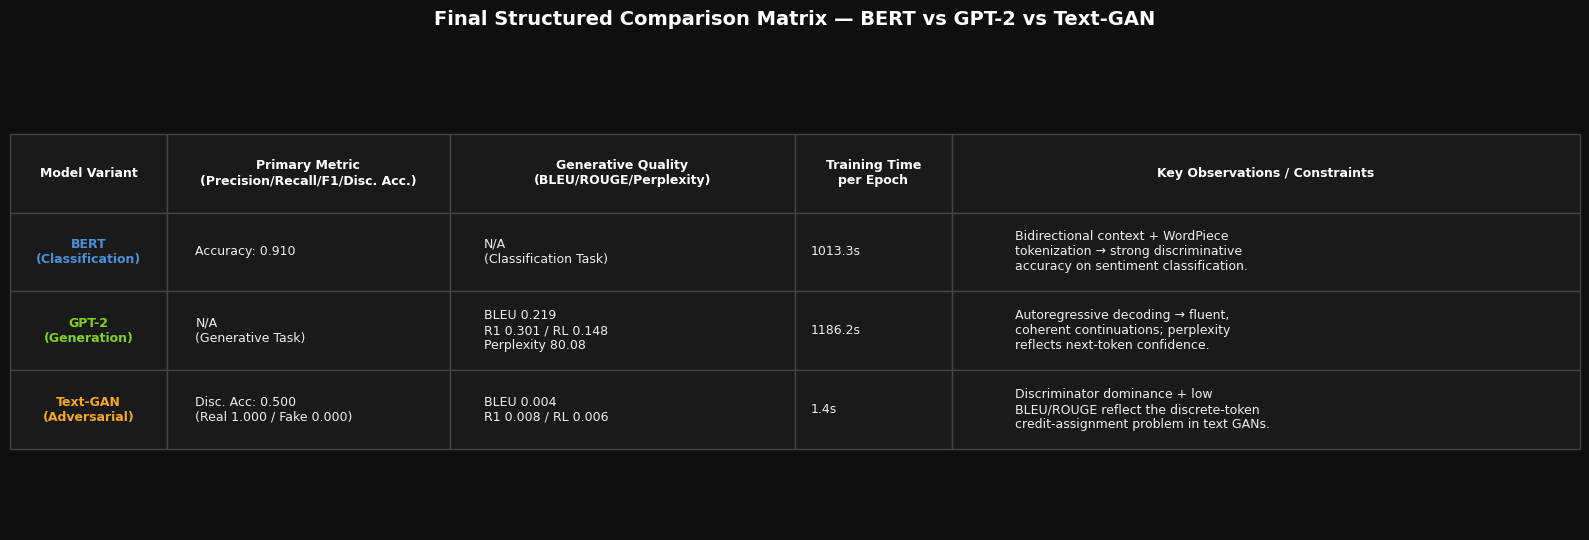

In [ ]:
# Final Structured Comparison Matrix — Visualization
import matplotlib.pyplot as plt
import numpy as np

rows = [
    ["BERT\n(Classification)",
     f"Accuracy: {bert_accuracy:.3f}",
     "N/A\n(Classification Task)",
     f"{bert_train_time:.1f}s",
     "Bidirectional context + WordPiece\ntokenization → strong discriminative\naccuracy on sentiment classification."],
    ["GPT-2\n(Generation)",
     "N/A\n(Generative Task)",
     f"BLEU {gpt_bleu:.3f}\nR1 {gpt_rouge1:.3f} / RL {gpt_rougeL:.3f}\nPerplexity {gpt_perplexity:.2f}",
     f"{gpt_train_time:.1f}s",
     "Autoregressive decoding → fluent,\ncoherent continuations; perplexity\nreflects next-token confidence."],
    ["Text-GAN\n(Adversarial)",
     f"Disc. Acc: {gan_strength:.3f}\n(Real {gan_real_acc:.3f} / Fake {gan_fake_acc:.3f})",
     f"BLEU {gan_bleu:.3f}\nR1 {gan_rouge1:.3f} / RL {gan_rougeL:.3f}",
     f"{gan_train_time:.1f}s",
     "Discriminator dominance + low\nBLEU/ROUGE reflect the discrete-token\ncredit-assignment problem in text GANs."],
]

col_labels = ["Model Variant", "Primary Metric\n(Precision/Recall/F1/Disc. Acc.)",
              "Generative Quality\n(BLEU/ROUGE/Perplexity)", "Training Time\nper Epoch",
              "Key Observations / Constraints"]

row_colors = ["#4A90D9", "#7ED321", "#F5A623"]

fig, ax = plt.subplots(figsize=(16, 5.5))
fig.patch.set_facecolor("#0f0f0f")
ax.set_facecolor("#0f0f0f")
ax.axis("off")

table = ax.table(cellText=rows, colLabels=col_labels, loc="center", cellLoc="left",
                  colWidths=[0.10, 0.18, 0.22, 0.10, 0.40])

table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 4.2)

for (r, c), cell in table.get_celld().items():
    cell.set_edgecolor("#444444")
    if r == 0:
        cell.set_facecolor("#1a1a1a")
        cell.set_text_props(color="white", fontweight="bold", ha="center")
    else:
        cell.set_facecolor("#1a1a1a")
        cell.set_text_props(color="#EEEEEE")
        if c == 0:
            cell.set_text_props(color=row_colors[r - 1], fontweight="bold", ha="center")

ax.set_title("Final Structured Comparison Matrix — BERT vs GPT-2 vs Text-GAN",
             color="white", fontsize=14, fontweight="bold", pad=20)

plt.tight_layout()
plt.savefig("comparison_matrix.png", dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()

* `import matplotlib.pyplot as plt` - Imports Matplotlib for data visualization.

* `import numpy as np` - Imports NumPy for numerical operations.

* `rows = [...]` - Stores the comparison data for the three NLP models.

* `col_labels = [...]` - Defines the table column headers.

* `row_colors = ["#4A90D9", "#7ED321", "#F5A623"]` - Defines the colors for each model.

* `fig, ax = plt.subplots(figsize=(16, 5.5))` - Creates a figure and axes for the table.

* `fig.patch.set_facecolor("#0f0f0f")` - Sets the figure background color.

* `ax.set_facecolor("#0f0f0f")` - Sets the axes background color.

* `ax.axis("off")` - Hides the axes.

* `table = ax.table(...)` - Creates the comparison table.

* `table.auto_set_font_size(False)` - Disables automatic font resizing.

* `table.set_fontsize(9)` - Sets the table font size.

* `table.scale(1, 4.2)` - Adjusts the table size.

* `for (r, c), cell in table.get_celld().items():` - Iterates through each table cell.

* `cell.set_edgecolor("#444444")` - Sets the border color of each cell.

* `if r == 0:` - Applies formatting to the header row.

* `cell.set_facecolor("#1a1a1a")` - Sets the cell background color.

* `cell.set_text_props(...)` - Styles the cell text.

* `if c == 0:` - Applies special formatting to the first column.

* `ax.set_title("Final Structured Comparison Matrix — BERT vs GPT-2 vs Text-GAN", ...)` - Sets the title of the table.

* `plt.tight_layout()` - Adjusts the layout to prevent overlapping elements.

* `plt.savefig("comparison_matrix.png", dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())` - Saves the comparison table as an image.

* `plt.show()` - Displays the comparison matrix.

# **Discussion:**

1. How tokenization differences affected the three models

The three models used different tokenization approaches because they were designed for different NLP tasks. BERT used the BertTokenizer, which applies WordPiece tokenization. This breaks unfamiliar words into smaller subwords, allowing BERT to understand context more effectively and achieve high sentiment classification accuracy on the IMDB dataset.

GPT-2 used the GPT2Tokenizer, which is based on Byte Pair Encoding (BPE). BPE efficiently represents common word patterns while still handling unknown words by splitting them into smaller units. This helped GPT-2 generate coherent movie review text, as reflected by its perplexity score of 80.08.

In contrast, the GAN used a simple custom vocabulary containing only the 2,000 most frequent words, where each word was mapped to an integer ID. While this simplified training, it limited the model's vocabulary and expressiveness. As a result, the generated text often contained unrelated or incoherent words, demonstrating that simple word-level tokenization is less effective for text generation than subword tokenization.

2. Analysis of the metric tradeoffs (e.g., why GANs struggle with discrete text sequences relative to autoregressive models like GPT)

The results highlight the strengths and limitations of each model. BERT achieved strong performance because it was specifically designed for text classification, using bidirectional contextual understanding to accurately classify movie reviews.

GPT-2 performed well as a text generator, producing fluent and natural-looking movie review text. Its perplexity of 80.08 indicates that it learned the statistical patterns of the training data reasonably well. Since GPT-2 generates one token at a time based on previously generated tokens, it can maintain sentence coherence more effectively than GAN-based text generation.

The GAN achieved a high Real Accuracy (0.9844) but a much lower Fake Accuracy (0.2949), resulting in a discriminator strength of 0.6396. This indicates that the discriminator easily recognized real text but the generator struggled to produce convincing fake text. Unlike images, text consists of discrete tokens that cannot be optimized directly through gradient descent. Although Gumbel-Softmax was used to approximate differentiable sampling, training remained unstable, resulting in generated text that lacked the coherence and fluency achieved by GPT-2.

# **References**

[1] Jacob Devlin, Ming-Wei Chang, Kenton Lee, and Kristina Toutanova. 2019. BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding. In Proceedings of the 2019 Conference of the North American Chapter of the Association for Computational Linguistics (NAACL-HLT), 4171–4186. https://doi.org/10.18653/v1/N19-1423

[2] Ian Goodfellow, Jean Pouget-Abadie, Mehdi Mirza, Bing Xu, David Warde-Farley, Sherjil Ozair, Aaron Courville, and Yoshua Bengio. 2014. Generative Adversarial Nets. In Advances in Neural Information Processing Systems (NeurIPS 27). https://doi.org/10.48550/arXiv.1406.2661

[3] Hugging Face. 2024. Transformers Documentation. Retrieved June 30, 2026 from https://huggingface.co/docs/transformers

[4] Jeremy Howard and Sebastian Ruder. 2018. Universal Language Model Fine-tuning for Text Classification. In Proceedings of the 56th Annual Meeting of the Association for Computational Linguistics (ACL), 328–339. https://doi.org/10.18653/v1/P18-1031

[5] Andrew L. Maas, Raymond E. Daly, Peter T. Pham, Dan Huang, Andrew Y. Ng, and Christopher Potts. 2011. Learning Word Vectors for Sentiment Analysis. In Proceedings of the 49th Annual Meeting of the Association for Computational Linguistics: Human Language Technologies, 142–150. https://aclanthology.org/P11-1015/

[6] Wes McKinney. 2022. Python for Data Analysis, 3rd ed. O'Reilly Media. https://pandas.pydata.org/

[7] Alec Radford, Jeffrey Wu, Rewon Child, David Luan, Dario Amodei, and Ilya Sutskever. 2019. Language Models are Unsupervised Multitask Learners. OpenAI. Retrieved June 30, 2026 from https://cdn.openai.com/better-language-models/language_models_are_unsupervised_multitask_learners.pdf

[8] Adam Paszke, Sam Gross, Francisco Massa, Adam Lerer, James Bradbury, Gregory Chanan, Trevor Killeen, Zeming Lin, Natalia Gimelshein, Luca Antiga, et al. 2019. PyTorch: An Imperative Style, High-Performance Deep Learning Library. In Advances in Neural Information Processing Systems (NeurIPS 32). https://proceedings.neurips.cc/paper/2019/hash/bdbca288fee7f92f2bfa9f7012727740-Abstract.html

[9] Fabian Pedregosa, Gaël Varoquaux, Alexandre Gramfort, Vincent Michel, Bertrand Thirion, Olivier Grisel, Mathieu Blondel, Peter Prettenhofer, Ron Weiss, Vincent Dubourg, et al. 2011. Scikit-learn: Machine Learning in Python. Journal of Machine Learning Research 12 (2011), 2825–2830. https://jmlr.org/papers/v12/pedregosa11a.html

[10] TensorFlow Authors. 2024. TensorFlow Documentation. Retrieved June 30, 2026 from https://www.tensorflow.org/